In [2]:
!pip install importlib_metadata
import subprocess
import sys
from importlib_metadata import version as pkg_version, PackageNotFoundError

packages = ["torch", "torchvision", "torchaudio", "tqdm", "matplotlib","scikit-learn", "seaborn", "kagglehub"]

print("####################################################################")
print("Checking packages and upgrading only if needed (local check)...")
print("-----------------------------------")

for pkg in packages:
    try:
        installed_version = pkg_version(pkg)
        print(f"{pkg} is installed (version {installed_version}). Checking for upgrade...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", pkg])
    except PackageNotFoundError:
        print(f"{pkg} is not installed. Installing now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("####################################################################")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [importlib_metadata]
####################################################################
Checking packages and upgrading only if needed (local check)...
-----------------------------------
torch is installed (version 2.10.0). Checking for upgrade...
torchvision is installed (version 0.25.0). Checking for upgrade...
torchaudio is installed (version 2.10.0). Checking for upgrade...
tqdm is installed (version 4.67.3). Checking for upgrade...
matplotlib is installed (version 3.10.8). Checking for upgrade...
scikit-learn is installed (version 1.8.0). Checking for upgrade...
seaborn is installed (version 0.13.2). Checking for upgrade...
kagglehub is installed (version 1.0.0). Checking for upgrade...
####################################################################


In [35]:
from utils import create_dataframe, OCTDataset
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from PIL import Image
import torchvision
from sklearn.preprocessing import LabelEncoder

In [13]:
# Download dataset if needed
DATA_PATH = kagglehub.dataset_download("mislamshawon/oct2017")
print("####################################################################################")
print("The path for the dataset is:", DATA_PATH)
print("####################################################################")

# Check folder exists
if os.path.exists(DATA_PATH):
    print("Data folder contents:", os.listdir(os.path.join(DATA_PATH)))
    print("####################################################################")
    print("Train folder contents:", os.listdir(os.path.join(DATA_PATH, "train")))
    print("####################################################################")
    print("Val folder contents:", os.listdir(os.path.join(DATA_PATH, "val")))
    print("####################################################################")
    print("Test folder contents:", os.listdir(os.path.join(DATA_PATH, "test")))
    print("####################################################################")
else:
    print("Path does not exist!")

100%|██████████| 5.38G/5.38G [21:25<00:00, 4.50MB/s]  

Extracting files...


####################################################################################
The path for the dataset is: /Users/georgedikaios/.cache/kagglehub/datasets/mislamshawon/oct2017/versions/1
####################################################################
Data folder contents: ['test', 'train', 'val']
####################################################################
Train folder contents: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
####################################################################
Val folder contents: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
####################################################################
Test folder contents: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
####################################################################


In [14]:
# Create separate DataFrames
train_df = create_dataframe("train", DATA_PATH)
val_df   = create_dataframe("val", DATA_PATH)
test_df  = create_dataframe("test", DATA_PATH)

sum_total_data = len(train_df)+len(val_df)+len(test_df)
print("####################################################################")
print("The total images in the dataset are:", (sum_total_data), "images")
print("####################################################################")

print("####################################################################")
print("The size of the imported data in each folder is:")
print("A) Train size:", len(train_df),"images [",len(train_df)/(sum_total_data) *100,"% ]")
print("B) Validation size:", len(val_df),"images [",len(val_df)/(sum_total_data) *100,"% ]")
print("C) Test size:", len(test_df),"images [",len(test_df)/(sum_total_data) *100,"% ]")
print("####################################################################")

####################################################################
The total images in the dataset are: 84130 images
####################################################################
####################################################################
The size of the imported data in each folder is:
A) Train size: 50580 images [ 60.12124093664567 % ]
B) Validation size: 16851 images [ 20.029715915844527 % ]
C) Test size: 16699 images [ 19.849043147509807 % ]
####################################################################


In [15]:
# Combine all splits into one df
data = []

for split in ["train", "val", "test"]:
    split_path = os.path.join(DATA_PATH, split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)
            data.append({
                "filepath": img_path,
                "label": class_name
            })

df = pd.DataFrame(data)

In [16]:
# We perform "Exploratory Data Analysis (EDA)" to check if data are stratified correctly.
# Moreover, we check if ratios are balanced.
print("####################################################################")
# Dataset Overview
print("Total images:", len(df))
print("####################################################################")
print("Class distribution (Full Dataset):")
print(df["label"].value_counts())
print("####################################################################")
print("####################################################################")
# Train / Val / Test Distribution
print("Train distribution:\n", train_df["label"].value_counts())
print("####################################################################")
print("Validation distribution:\n", val_df["label"].value_counts())
print("####################################################################")
print("Test distribution:\n", test_df["label"].value_counts())
print("####################################################################")

####################################################################
Total images: 84130
####################################################################
Class distribution (Full Dataset):
label
CNV       37343
NORMAL    26464
DME       11563
DRUSEN     8760
Name: count, dtype: int64
####################################################################
####################################################################
Train distribution:
 label
CNV       22436
NORMAL    15905
DME        6952
DRUSEN     5287
Name: count, dtype: int64
####################################################################
Validation distribution:
 label
CNV       7475
NORMAL    5299
DME       2318
DRUSEN    1759
Name: count, dtype: int64
####################################################################
Test distribution:
 label
CNV       7432
NORMAL    5260
DME       2293
DRUSEN    1714
Name: count, dtype: int64
####################################################################


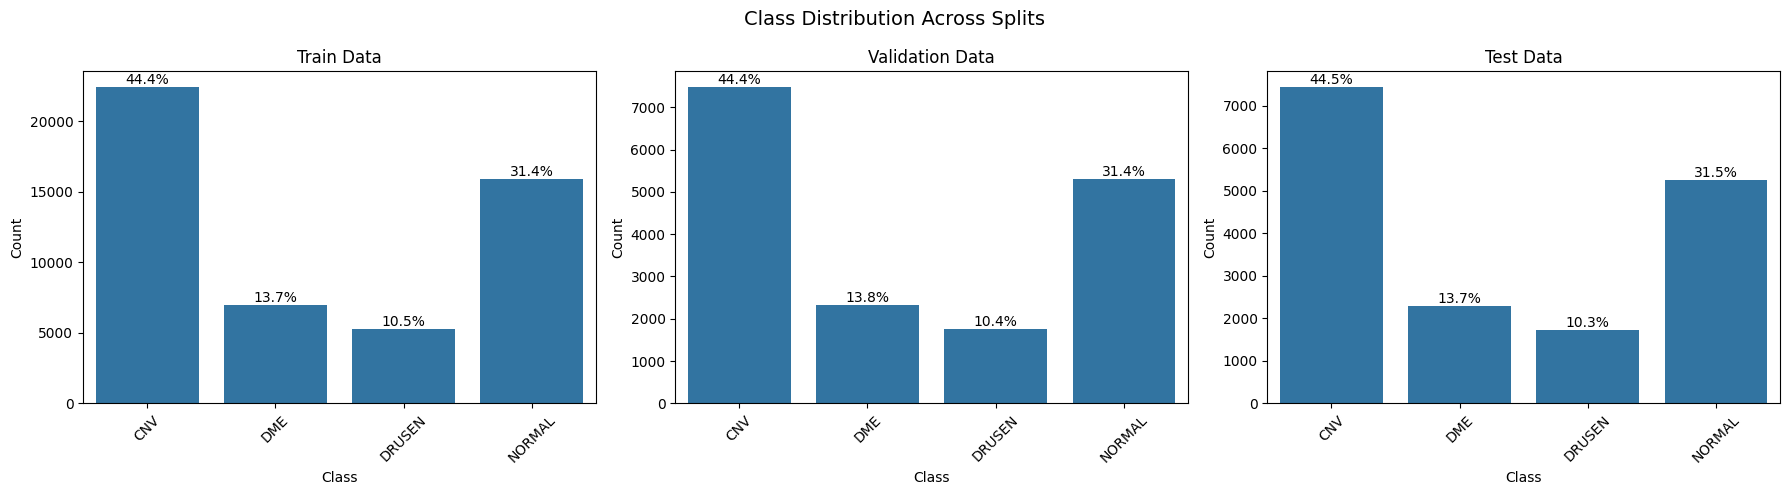

In [17]:
# Plots for class distribution in each split
fig, axes = plt.subplots(1, 3, figsize=(18,5))

datasets = [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]

for ax, (title, df) in zip(axes, datasets):

    sns.countplot(x="label", data=df, ax=ax)

    total = len(df)

    for p in ax.patches:
        percentage = 100 * p.get_height() / total
        ax.annotate(
            f"{percentage:.1f}%",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom'
        )

    ax.set_title(f"{title} Data")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Class Distribution Across Splits", fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# Check for Corrupted Images
bad_images = []

for path in df["filepath"]:
    try:
        Image.open(path).verify()
    except:
        bad_images.append(path)

print("####################################################################")
print("Corrupted images:", len(bad_images))
print("####################################################################")

####################################################################
Corrupted images: 0
####################################################################


In [27]:
# Check Image Sizes for the first 100 images
N_size = 100 # change N_size = 100 here
sizes = []

for i in range(N_size):
    img = Image.open(df.iloc[i]["filepath"])
    sizes.append(img.size)

sizes = np.array(sizes)

print("####################################################################")
print("Width range:", sizes[:,0].min(), "-", sizes[:,0].max())
print("####################################################################")
print("Height range:", sizes[:,1].min(), "-", sizes[:,1].max())
print("####################################################################")

####################################################################
Width range: 512 - 1536
####################################################################
Height range: 496 - 496
####################################################################


In [31]:
# Check Image Mode
#  "L"	  is Grayscale image
# "RGB"	  is Color image
# "RGBA"  is Color image with alpha

print("####################################################################")
print("Image mode for the first 20 images is:")
# Check first 20 images
for i in range(20):
    img_path = df.iloc[i]["filepath"]
    img = Image.open(img_path)
    print(img.mode, end=", ")
print("\n####################################################################")

def is_grayscale(img_path):
    img = Image.open(img_path).convert("RGB")
    img_array = np.array(img)

    # Check if R == G == B
    return np.all(img_array[:,:,0] == img_array[:,:,1]) and \
           np.all(img_array[:,:,1] == img_array[:,:,2])

# Sometimes grayscale images are saved as RGB (3 identical channels).
print("####################################################################")
print("Check if RGB channels are identical for the first 20 images:")
# Test first 20 images
for i in range(20):
    path = df.iloc[i]["filepath"]
    print(is_grayscale(path), end=", ")
print("\n####################################################################")

# Confirm whether all images have similar dimensions
sizes = []

for path in df["filepath"][:500]:  # check first 500 images
    img = Image.open(path)
    sizes.append(img.size)  # (width, height)

unique_sizes = set(sizes) # PIL .size → (width, height)
print("####################################################################")
print("Check if images have similar dimensions for the first 500 images:")
print("Unique sizes found (width, height):", unique_sizes)
print("####################################################################")

####################################################################
Image mode for the first 20 images is:
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, 
####################################################################
####################################################################
Check if RGB channels are identical for the first 20 images:
True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, 
####################################################################
####################################################################
Check if images have similar dimensions for the first 500 images:
Unique sizes found (width, height): {(1024, 496), (512, 496), (1536, 496), (768, 496)}
####################################################################


In [32]:
img = Image.open(df.iloc[0]["filepath"])
print("####################################################################")
print("(height, width) :", np.array(img).shape)
height, width = np.array(img).shape[0], np.array(img).shape[1]
aspect_ratio = width / height
print("General aspect ratio is :", aspect_ratio)
print("####################################################################")

####################################################################
(height, width) : (496, 1536)
General aspect ratio is : 3.096774193548387
####################################################################


In [36]:
# Encode Labels to Numbers
le = LabelEncoder()

train_df["label_encoded"] = le.fit_transform(train_df["label"])
val_df["label_encoded"] = le.transform(val_df["label"])
test_df["label_encoded"] = le.transform(test_df["label"])
print("####################################################################")
print("The names of the classes in OCT classification are:")
print("Classes:", le.classes_)
print("Classes have been labeled as 0, 1, 2, 3.")
print("####################################################################")

####################################################################
The names of the classes in OCT classification are:
Classes: ['CNV' 'DME' 'DRUSEN' 'NORMAL']
Classes have been labeled as 0, 1, 2, 3.
####################################################################


####################################################################


Using batch size: 32
####################################################################
####################################################################
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Example labels: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0656123].


tensor([0, 0, 0, 3, 3, 0, 0, 1, 3, 1])
####################################################################


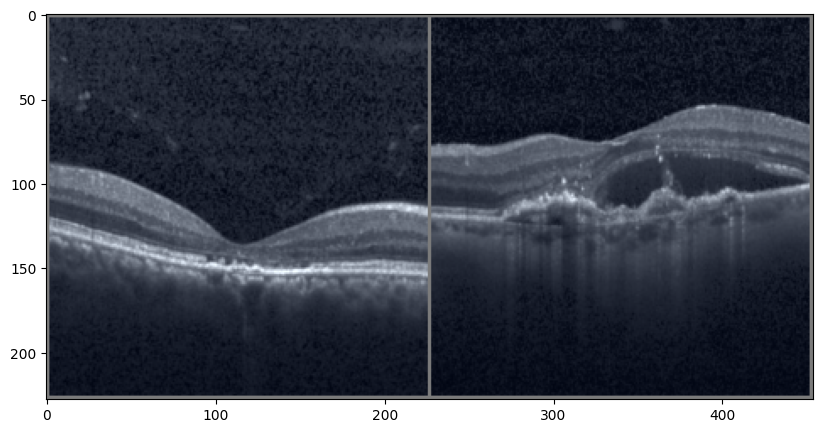

In [37]:
# Image transformation
transform_no_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Pass Transform Into Dataset
train_dataset = OCTDataset(train_df, transform=transform_no_aug)
val_dataset = OCTDataset(val_df, transform=transform_no_aug)
test_dataset = OCTDataset(test_df, transform=transform_no_aug)

# Create DataLoaders
print("####################################################################")
while True:
    BATCH_SIZE = int(input("Enter batch size (e.g., 32, 64, 128): "))
    if BATCH_SIZE % 8 != 0 and BATCH_SIZE != 1:
        print("Please enter a batch size that is a multiple of 8")
    else:
        break
print("Using batch size:", BATCH_SIZE)
print("####################################################################")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print("####################################################################")
print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Example labels:", labels[:10])
print("####################################################################")
grid = torchvision.utils.make_grid(images[:2].cpu(), nrow=2)
plt.figure(figsize=(10,5))
plt.imshow(grid.permute(1,2,0) * 0.229 + 0.485)  # de-normalize approx
plt.show()